# Numerical Simulation Laboratory - Notebook 10

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

## Exercise 10.1

The genetic algorithm was parallelized by implementing a Parallel Tempering algorithm. Each CPU thread implements a modified version of the genetic algorithm in which one of the 4 implemented mutations is chosen as a Metropolis move. Every parallel program has a different temperature chosen with a geometric distribution $T_i=T_\text{min}(\frac{T_\text{max}}{T_\text{min}})^\frac{i}{N-1}$, where $N$ is the number of parallel programs and $i$ is the program's rank. The algorithm works by having different individuals evolve in parallel at different temperatures. These temperatures change the exploratory behavior of the Metropolis algorithm: higher temperatures enable broader explorations, while lower temperatures focus on refining the optimal solutions. Every $10$ steps an exchange move is proposed, where adjacent temperatures exchange their individual with an acceptance probability $A=\min\left(1, e^{-(\beta_j-\beta_i)[L(\vec{x_i})-L(\vec{x_j})]}\right)$. If the move is accepted the programs swap their individuals. After the execution of the algorithm the optimal solution is the best individual found by the lowest temperature simulation.

## Exercise 10.2

Best path length parallel tempering: 65.1666
Best path length non-parallel genetic algorithm: 157.099


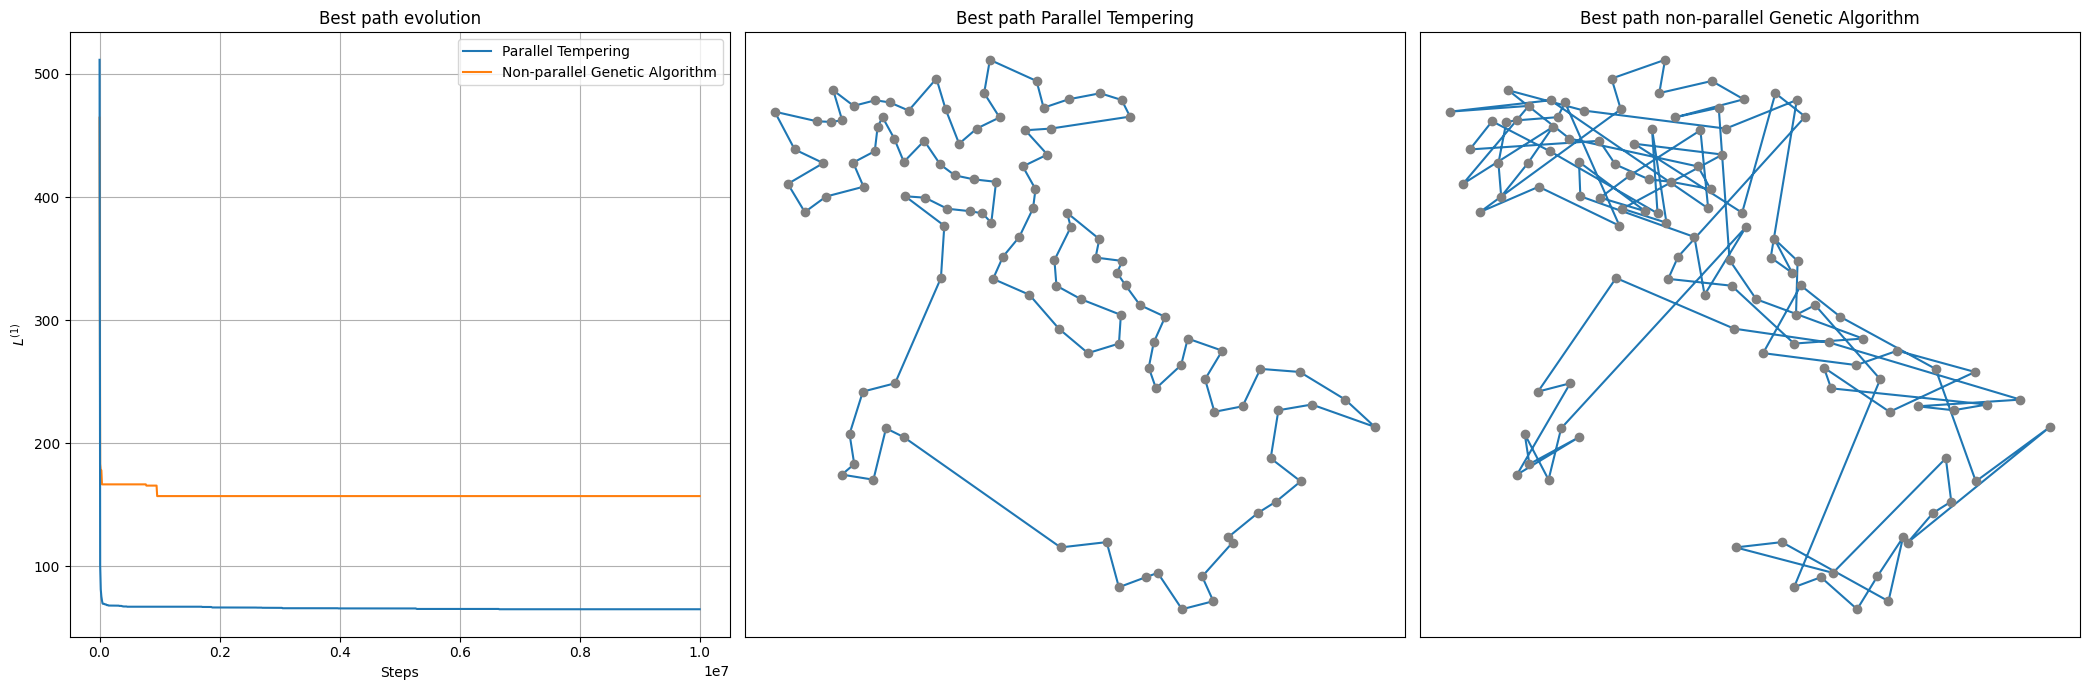

In [ ]:
optimal_PT = np.loadtxt("../10-Exercises/OUTPUT/best_PT.out", dtype=int) - 1
optimal_PT = np.append(optimal_PT, optimal_PT[0])
optimal_SC = np.loadtxt("../10-Exercises/OUTPUT/best_single.out", dtype=int) - 1
optimal_SC = np.append(optimal_SC, optimal_SC[0])
cities = np.loadtxt("../10-Exercises/cap_prov_ita.dat")

steps_PT, history_PT = np.loadtxt("../10-Exercises/OUTPUT/history_PT.out", unpack=True)
steps_SC, history_SC = np.loadtxt("../10-Exercises/OUTPUT/history_single.out", unpack=True)

fig, axs = plt.subplots(1, 3, figsize=(21,7))

axs[0].plot(steps_PT, history_PT, zorder=10, label="Parallel Tempering")
axs[0].plot(steps_SC, history_SC, label="Non-parallel Genetic Algorithm")

axs[0].set_xlabel("Steps")
axs[0].set_ylabel("$L^{(1)}$")
axs[0].set_title("Best path evolution")
axs[0].legend()
axs[0].grid()

axs[1].plot(cities[optimal_PT,0], cities[optimal_PT,1])
axs[1].scatter(cities[:,0], cities[:,1], color="grey", zorder=10)
axs[1].get_xaxis().set_visible(False)
axs[1].get_yaxis().set_visible(False)
axs[1].set_title("Best path Parallel Tempering");

axs[2].plot(cities[optimal_SC,0], cities[optimal_SC,1])
axs[2].scatter(cities[:,0], cities[:,1], color="grey", zorder=10)
axs[2].get_xaxis().set_visible(False)
axs[2].get_yaxis().set_visible(False)
axs[2].set_title("Best path non-parallel Genetic Algorithm");
plt.tight_layout()

print(f"Best path length parallel tempering: {history_PT[-1]}")
print(f"Best path length non-parallel genetic algorithm: {history_SC[-1]}")

The PT algorithm was run for $10^7$ generations with $16$ parallel programs in a time of about 30s. To show the improvement with respect to the non-parallel genetic algorithm the latter was run with a population of $16$ for $10^7$ generations, taking 5m37s to run. It is clear from the evolution of the best path that the parallel tempering converges faster than the non-parallel algorithm and to a better solution. This means that it explores the space better than the low population non-parallel algorithm, that remains stuck for millions of generations in a local minimum. The fact that there are no intersection in the path generated by the PT algorithm is a sign of the good functioning of the algorithm.